# Robustness and Sensitivity Analysis

**Chapter 8: Feature Engineering**
**Section Reference**: 8.6 - Combining Features and Controlling Search

**Docker image**: `ml4t`

## Purpose

A robust signal maintains performance across reasonable variations in
parameters, regimes, and implementation choices. This notebook teaches how
to assess robustness through parameter sweeps, regime conditioning, and
signal × state interactions.

## Learning Objectives

1. Conduct parameter sweeps as response-surface analysis
2. Define robustness as the **breadth of the near-optimal region**
3. Analyze regime-conditional IC with clean conditioning variables
4. Build signal × state interaction features (gating, scaling, conditional)
5. Apply RAS correction for parameter snooping

## Data Policy

All examples use **real ETF data**.

In [1]:
"""Robustness and Sensitivity Analysis - parameter sweeps, regime conditioning, and signal interaction features."""

from __future__ import annotations

import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.metrics import pooled_ic
from plotly.subplots import make_subplots

from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS  # activates the ml4t Plotly template on import

warnings.filterwarnings("ignore")

In [2]:
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Data Loading

In [4]:
from data import load_etfs

etfs = load_etfs()

# Sealed-holdout boundary (setup.yaml `evaluation.holdout_start`). Parameter
# sweeps and robustness diagnostics are development decisions; the sealed
# holdout must not inform them (see the rule in
# 06_strategy_definition/02_cv_foundations). Clamp the analysis window so an
# END_DATE override can never reach into the holdout - every IC below (sweep,
# RAS, regime-conditional, implementation variants) sees only pre-holdout data.
setup = yaml.safe_load((get_case_study_dir("etfs") / "config" / "setup.yaml").read_text())
HOLDOUT_START = setup["evaluation"]["holdout_start"]
end_date = min(
    datetime.strptime(END_DATE, "%Y-%m-%d"),
    datetime.strptime(HOLDOUT_START, "%Y-%m-%d"),
)

etfs_filtered = etfs.filter(
    (pl.col("timestamp") >= datetime.strptime(START_DATE, "%Y-%m-%d"))
    & (pl.col("timestamp") < end_date)
).sort(["symbol", "timestamp"])

print(f"ETF data: {len(etfs_filtered):,} rows")
print(f"Symbols: {etfs_filtered['symbol'].n_unique()}")
print(f"Date range: {etfs_filtered['timestamp'].min()} to {etfs_filtered['timestamp'].max()}")

ETF data: 225,336 rows
Symbols: 100
Date range: 2015-01-02 to 2023-12-29


In [5]:
prices_wide = (
    etfs_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
)

symbols = [c for c in prices_wide.columns if c != "timestamp"]
print(f"Computing features for {len(symbols)} symbols")

Computing features for 100 symbols


## 2. IC Computation Helpers

All IC statistics use HAC standard errors via the `ml4t-diagnostic` library
to account for serial dependence.

In [6]:
from ml4t.diagnostic.metrics import compute_ic_hac_stats


def _ic_stats_with_icir(ic_series: np.ndarray, label_horizon: int | None = None) -> dict:
    """Compute HAC-adjusted IC stats and add ICIR (mean IC / std IC).

    ``label_horizon`` is forwarded to the HAC bandwidth so overlapping
    forward-return labels get a Newey-West lag of at least ``horizon - 1``.
    """
    stats = compute_ic_hac_stats(ic_series, label_horizon=label_horizon)
    std_ic = float(np.std(ic_series[~np.isnan(ic_series)], ddof=1))
    stats["icir"] = stats["mean_ic"] / std_ic if std_ic > 0 else np.nan
    return stats

### Compute IC Series for a Momentum Signal
For each date, compute cross-sectional Spearman IC between the momentum
signal and forward returns.

In [7]:
def compute_momentum_ic_series(
    prices_df: pl.DataFrame,
    symbols: list[str],
    lookback: int,
    forward_horizon: int = 20,
) -> np.ndarray:
    """Compute daily cross-sectional IC series for a momentum signal."""
    momentum = prices_df.select(
        pl.col("timestamp"),
        *[(pl.col(s) / pl.col(s).shift(lookback) - 1).alias(s) for s in symbols],
    )
    forward_ret = prices_df.select(
        pl.col("timestamp"),
        *[(pl.col(s).shift(-forward_horizon) / pl.col(s) - 1).alias(s) for s in symbols],
    )

    mom_long = momentum.unpivot(index="timestamp", variable_name="symbol", value_name="signal")
    fwd_long = forward_ret.unpivot(index="timestamp", variable_name="symbol", value_name="fwd_ret")

    merged = mom_long.join(fwd_long, on=["timestamp", "symbol"], how="inner").drop_nulls()

    ics = []
    for date in merged["timestamp"].unique().sort().to_list():
        day_data = merged.filter(pl.col("timestamp") == date)
        if len(day_data) >= 10:
            sig_vals = day_data["signal"].to_numpy()
            ret_vals = day_data["fwd_ret"].to_numpy()
            valid = np.isfinite(sig_vals) & np.isfinite(ret_vals)
            if np.sum(valid) >= 10:
                ic = pooled_ic(sig_vals[valid], ret_vals[valid])
                if not np.isnan(ic):
                    ics.append(ic)

    return np.array(ics)

## 3. Parameter Sweep: Response Surface

We vary the momentum lookback period and observe how IC changes. The goal
is not to find the "best" parameter but to understand the **response
surface** and identify a **robust region**.

**One knob at a time**: The sweep varies lookback while holding everything
else constant (return metric, normalization, label horizon). Changing
multiple parameters simultaneously makes it impossible to attribute
performance changes to any single choice.

In [8]:
LOOKBACK_RANGE = [5, 10, 21, 42, 63, 126, 189, 252]
FORWARD_HORIZON = 20

sweep_results = {}

print("Parameter Sweep: Momentum Lookback")
print("-" * 60)

for lb in LOOKBACK_RANGE:
    ic_series = compute_momentum_ic_series(prices_wide, symbols, lb, FORWARD_HORIZON)

    if len(ic_series) >= 20:
        stats_result = _ic_stats_with_icir(ic_series, label_horizon=FORWARD_HORIZON)
        stats_result["ics"] = ic_series  # Keep for later use
        sweep_results[lb] = stats_result

        sig = (
            "***"
            if stats_result["p_value"] < 0.01
            else (
                "**"
                if stats_result["p_value"] < 0.05
                else ("*" if stats_result["p_value"] < 0.10 else "")
            )
        )

        print(
            f"  Lookback {lb:3d}d: IC={stats_result['mean_ic']:.4f}, "
            f"ICIR={stats_result['icir']:.2f}, "
            f"HAC t={stats_result['t_stat']:.2f}{sig}"
        )

Parameter Sweep: Momentum Lookback
------------------------------------------------------------


  Lookback   5d: IC=-0.0097, ICIR=-0.03, HAC t=-0.75


  Lookback  10d: IC=-0.0139, ICIR=-0.04, HAC t=-0.84


  Lookback  21d: IC=-0.0245, ICIR=-0.08, HAC t=-1.31


  Lookback  42d: IC=-0.0272, ICIR=-0.09, HAC t=-1.29


  Lookback  63d: IC=-0.0195, ICIR=-0.06, HAC t=-0.84


  Lookback 126d: IC=0.0136, ICIR=0.04, HAC t=0.59


  Lookback 189d: IC=0.0241, ICIR=0.08, HAC t=1.01


  Lookback 252d: IC=0.0011, ICIR=0.00, HAC t=0.05


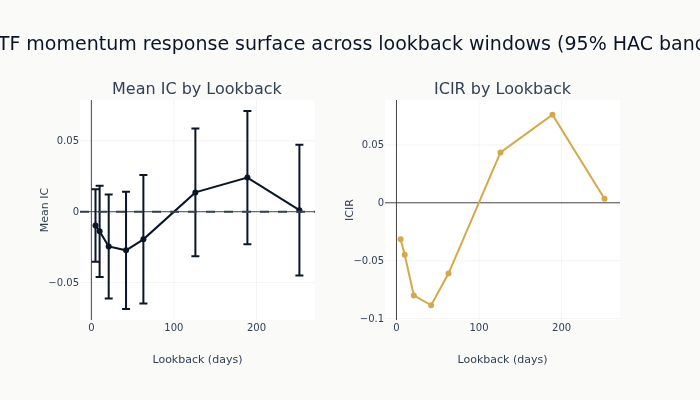

In [9]:
# Visualize response surface
if sweep_results:
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=["Mean IC by Lookback", "ICIR by Lookback"],
        horizontal_spacing=0.13,
    )

    lbs = list(sweep_results.keys())
    mean_ics = [sweep_results[lb]["mean_ic"] for lb in lbs]
    icirs = [sweep_results[lb]["icir"] for lb in lbs]
    hac_ses = [sweep_results[lb]["hac_se"] for lb in lbs]

    fig.add_trace(
        go.Scatter(
            x=lbs,
            y=mean_ics,
            mode="lines+markers",
            name="Mean IC",
            line=dict(color=COLORS["blue"]),
            error_y=dict(type="data", array=[1.96 * se for se in hac_ses]),
        ),
        row=1,
        col=1,
    )
    fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)

    fig.add_trace(
        go.Scatter(
            x=lbs,
            y=icirs,
            mode="lines+markers",
            name="ICIR",
            line=dict(color=COLORS["amber"]),
        ),
        row=1,
        col=2,
    )

    fig.update_layout(
        title="ETF momentum response surface across lookback windows (95% HAC band)",
        height=400,
        showlegend=False,
    )
    fig.update_xaxes(title_text="Lookback (days)", row=1, col=1)
    fig.update_xaxes(title_text="Lookback (days)", row=1, col=2)
    fig.update_yaxes(title_text="Mean IC", row=1, col=1)
    fig.update_yaxes(title_text="ICIR", row=1, col=2)

    fig.show()

## 4. Robustness: Breadth of Near-Optimal Region

Robustness is **not** a scalar score (mean/std ratio). It is the breadth
of the near-optimal region: how many parameter values achieve performance
within 90% of the best. A robust signal has a broad plateau; a fragile
signal has a narrow peak.

In [10]:
def compute_robust_region(
    sweep_results: dict[int, dict],
    metric: str = "icir",
    threshold_pct: float = 0.90,
) -> dict:
    """Compute the robust region as parameters within threshold_pct of best."""
    if not sweep_results:
        return {}

    params = list(sweep_results.keys())
    values = [sweep_results[p][metric] for p in params]

    best_idx = np.argmax(values)
    best_param = params[best_idx]
    best_value = values[best_idx]
    threshold = best_value * threshold_pct

    robust_params = [p for p, v in zip(params, values, strict=False) if v >= threshold]

    return {
        "best_param": best_param,
        "best_value": best_value,
        "threshold": threshold,
        "robust_params": robust_params,
        "robust_fraction": len(robust_params) / len(params),
        "robust_range": [min(robust_params), max(robust_params)] if robust_params else None,
    }

In [11]:
if sweep_results:
    robustness = compute_robust_region(sweep_results, metric="icir", threshold_pct=0.90)

    print(f"Best lookback: {robustness['best_param']} days (ICIR = {robustness['best_value']:.2f})")
    print(f"90% threshold: ICIR >= {robustness['threshold']:.2f}")
    print(f"Robust parameters: {robustness['robust_params']}")
    rr = robustness["robust_range"]
    print(f"Robust range: {rr[0]} to {rr[1]} days" if rr else "Robust range: None")
    print(f"Robust fraction: {robustness['robust_fraction']:.0%} of tested parameters")

    frac = robustness["robust_fraction"]
    band = ">50%" if frac >= 0.5 else "25-50%" if frac >= 0.25 else "<25%"
    print(f"\nRobust fraction {frac:.0%} ({band} of parameters near-optimal)")

Best lookback: 189 days (ICIR = 0.08)
90% threshold: ICIR >= 0.07
Robust parameters: [189]
Robust range: 189 to 189 days
Robust fraction: 12% of tested parameters

Robust fraction 12% (<25% of parameters near-optimal)


In [12]:
# Visualize robust region
if sweep_results and robustness:
    fig = go.Figure()

    lbs = list(sweep_results.keys())
    icirs = [sweep_results[lb]["icir"] for lb in lbs]

    fig.add_trace(
        go.Scatter(
            x=lbs,
            y=icirs,
            mode="lines+markers",
            name="ICIR",
            line=dict(color=COLORS["blue"], width=2),
        )
    )

    fig.add_hline(
        y=robustness["threshold"],
        line_dash="dash",
        line_color=COLORS["amber"],
        annotation_text=f"90% of best ({robustness['threshold']:.2f})",
        annotation_position="bottom left",
    )

    if robustness["robust_range"]:
        fig.add_vrect(
            x0=robustness["robust_range"][0],
            x1=robustness["robust_range"][1],
            fillcolor=COLORS["positive"],
            opacity=0.3,
            line_width=0,
            annotation_text="Robust region",
            annotation_position="top right",
        )

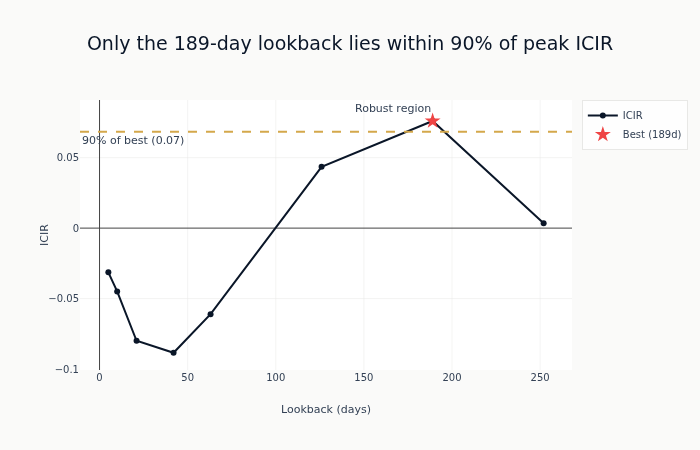

In [13]:
# Add best-point marker and display
if sweep_results and robustness:
    fig.add_trace(
        go.Scatter(
            x=[robustness["best_param"]],
            y=[robustness["best_value"]],
            mode="markers",
            name=f"Best ({robustness['best_param']}d)",
            marker=dict(color=COLORS["negative"], size=12, symbol="star"),
        )
    )

    fig.update_layout(
        title="Only the 189-day lookback lies within 90% of peak ICIR",
        xaxis_title="Lookback (days)",
        yaxis_title="ICIR",
        height=450,
    )
    fig.show()

### RAS Correction for Parameter Snooping

After sweeping N parameter combinations, the best IC is upward-biased.
RAS corrects for correlation-aware multiple testing - nearby parameters
produce correlated IC estimates and count as fewer independent tests.

In [14]:
from ml4t.diagnostic.evaluation.stats import (
    rademacher_complexity,
    ras_ic_adjustment,
)

if sweep_results:
    ic_matrix = []
    for lb in LOOKBACK_RANGE:
        ic_s = compute_momentum_ic_series(prices_wide, symbols, lb, FORWARD_HORIZON)
        if len(ic_s) >= 20:
            ic_matrix.append(ic_s)

    if len(ic_matrix) >= 2:
        min_len = min(len(s) for s in ic_matrix)
        ic_matrix_aligned = np.array([s[:min_len] for s in ic_matrix])  # (N strategies, T)
        best_ic_values = np.array([np.mean(s) for s in ic_matrix_aligned])

        # complexity is the empirical Rademacher complexity R-hat, NOT the count
        # of parameters tested. It expects a (T periods x N strategies) matrix and
        # measures how correlated the swept ICs are (correlated -> fewer effective
        # independent tests -> smaller snooping penalty).
        r_hat = rademacher_complexity(ic_matrix_aligned.T, random_state=42)
        # The snooping bias is about the cherry-picked HIGHEST IC, so deflate that.
        best_idx = int(np.argmax(best_ic_values))
        ras_adjusted = ras_ic_adjustment(
            observed_ic=best_ic_values,
            complexity=r_hat,
            n_samples=min_len,
            kappa=0.05,
        )

        print("=== RAS Correction for Parameter Snooping ===\n")
        print(f"Best uncorrected IC:           {best_ic_values[best_idx]:.4f}")
        print(f"Rademacher complexity (R-hat): {r_hat:.4f}")
        print(f"RAS-adjusted IC (lower bound): {ras_adjusted[best_idx]:.4f}")
        print(f"Parameters tested:             {len(ic_matrix)}")
        print(f"Time periods:                  {min_len}")

=== RAS Correction for Parameter Snooping ===

Best uncorrected IC:           0.0260
Rademacher complexity (R-hat): 0.0098
RAS-adjusted IC (lower bound): 0.0021
Parameters tested:             8
Time periods:                  1992


## 5. Regime-Conditional Performance

A robust signal maintains predictive power across market regimes. We use
42-day realized volatility on SPY as a clean, pre-defined conditioning
variable. Tercile thresholds use expanding-window percentiles to avoid
lookahead bias.

**Warning**: Avoid conditioning on variables derived from the signal itself.

In [15]:
spy_prices = prices_wide.select(["timestamp", "SPY"])

spy_vol = spy_prices.with_columns(
    (pl.col("SPY").pct_change().rolling_std(42) * np.sqrt(252)).alias("realized_vol")
)

# Expanding-window tercile thresholds
spy_vol = spy_vol.with_columns(
    pl.col("realized_vol")
    .rolling_quantile(0.33, window_size=100_000, min_samples=63)
    .alias("_q33"),
    pl.col("realized_vol")
    .rolling_quantile(0.67, window_size=100_000, min_samples=63)
    .alias("_q67"),
)

spy_vol = spy_vol.with_columns(
    pl.when(pl.col("realized_vol") < pl.col("_q33"))
    .then(pl.lit("low_vol"))
    .when(pl.col("realized_vol") > pl.col("_q67"))
    .then(pl.lit("high_vol"))
    .otherwise(pl.lit("normal_vol"))
    .alias("vol_regime")
).drop(["_q33", "_q67"])

print("Volatility Regime Distribution:")
spy_vol.group_by("vol_regime").len().sort("vol_regime")

Volatility Regime Distribution:


vol_regime,len
str,u32
"""high_vol""",854
"""low_vol""",600
"""normal_vol""",810


### Compute Regime-Conditional IC
Split the IC series by volatility regime to check signal stability.

In [16]:
def compute_regime_ic(
    prices_df: pl.DataFrame,
    regime_df: pl.DataFrame,
    symbols: list[str],
    lookback: int = 126,
    forward_horizon: int = 20,
) -> dict[str, dict]:
    """Compute HAC-adjusted IC statistics by regime."""
    momentum = prices_df.select(
        pl.col("timestamp"),
        *[(pl.col(s) / pl.col(s).shift(lookback) - 1).alias(s) for s in symbols],
    )
    forward_ret = prices_df.select(
        pl.col("timestamp"),
        *[(pl.col(s).shift(-forward_horizon) / pl.col(s) - 1).alias(s) for s in symbols],
    )

    mom_long = momentum.unpivot(index="timestamp", variable_name="symbol", value_name="signal")
    fwd_long = forward_ret.unpivot(index="timestamp", variable_name="symbol", value_name="fwd_ret")

    merged = (
        mom_long.join(fwd_long, on=["timestamp", "symbol"], how="inner")
        .join(regime_df.select(["timestamp", "vol_regime"]), on="timestamp", how="inner")
        .drop_nulls()
    )

    regime_results = {}
    for regime in merged["vol_regime"].unique().to_list():
        regime_data = merged.filter(pl.col("vol_regime") == regime)
        ics = []
        for date in regime_data["timestamp"].unique().sort().to_list():
            day_data = regime_data.filter(pl.col("timestamp") == date)
            if len(day_data) >= 10:
                sig = day_data["signal"].to_numpy()
                ret = day_data["fwd_ret"].to_numpy()
                valid = np.isfinite(sig) & np.isfinite(ret)
                if np.sum(valid) >= 10:
                    ic = pooled_ic(sig[valid], ret[valid])
                    if not np.isnan(ic):
                        ics.append(ic)

        if ics:
            stats = _ic_stats_with_icir(np.array(ics), label_horizon=forward_horizon)
            stats["ics"] = np.array(ics)
            regime_results[regime] = stats

    return regime_results

In [17]:
if spy_vol is not None:
    regime_ic = compute_regime_ic(prices_wide, spy_vol, symbols)

    print(f"{'Regime':<15} {'Mean IC':>10} {'ICIR':>8} {'HAC t':>10} {'p-value':>10}")
    print("-" * 60)

    for regime in ["low_vol", "normal_vol", "high_vol"]:
        if regime in regime_ic:
            r = regime_ic[regime]
            sig = "*" if r["p_value"] < 0.05 else ""
            print(
                f"{regime:<15} {r['mean_ic']:>10.4f} {r['icir']:>8.2f} "
                f"{r['t_stat']:>10.2f}{sig} {r['p_value']:>10.4f}"
            )

    if len(regime_ic) > 1:
        ic_values = [r["mean_ic"] for r in regime_ic.values()]
        ic_range = max(ic_values) - min(ic_values)
        print(f"\nIC range across regimes: {ic_range:.4f}")
        if ic_range > 0.04:
            print("IC range > 0.04 across regimes - interaction features are warranted")
        else:
            print("IC range <= 0.04 across regimes - signal does not depend on regime")

Regime             Mean IC     ICIR      HAC t    p-value
------------------------------------------------------------
low_vol             0.0708     0.25       2.06*     0.0395
normal_vol          0.0253     0.11       0.98     0.3258
high_vol           -0.0344    -0.09      -0.78     0.4359

IC range across regimes: 0.1052
IC range > 0.04 across regimes - interaction features are warranted


### Conditional IC Distribution by Regime

Box plots of the daily IC observations within each volatility tercile, with
the raw daily ICs overlaid, show how the distribution shifts across regimes -
not just the mean, but the spread and skew.

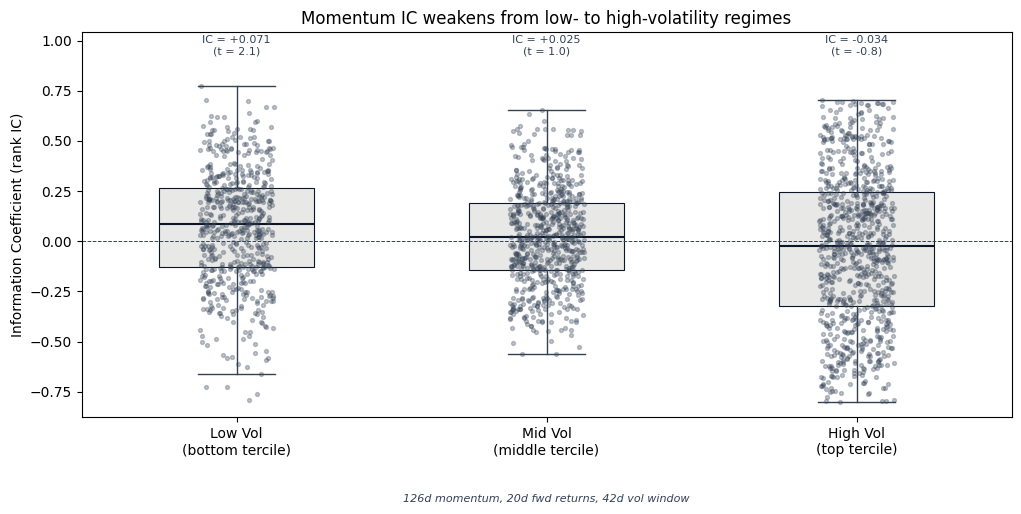

In [18]:
if spy_vol is not None and regime_ic:
    fig_mpl, ax = plt.subplots(figsize=(12, 5))

    regime_order = ["low_vol", "normal_vol", "high_vol"]
    regime_labels = [
        "Low Vol\n(bottom tercile)",
        "Mid Vol\n(middle tercile)",
        "High Vol\n(top tercile)",
    ]
    ic_data = [regime_ic[r]["ics"] for r in regime_order if r in regime_ic]
    positions = list(range(1, len(ic_data) + 1))

    bp = ax.boxplot(
        ic_data,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,  # every point is drawn by the jittered overlay below
        medianprops=dict(color=COLORS["blue"], linewidth=1.5),
        whiskerprops=dict(color=COLORS["neutral"]),
        capprops=dict(color=COLORS["neutral"]),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(COLORS["silver_muted"])
        patch.set_edgecolor(COLORS["blue"])
        patch.set_linewidth(0.8)

    for i, (ics, pos) in enumerate(zip(ic_data, positions, strict=False)):
        jitter = np.random.default_rng(SEED).uniform(-0.12, 0.12, size=len(ics))
        ax.scatter(pos + jitter, ics, s=8, alpha=0.3, color=COLORS["neutral"], zorder=3)

    # Add headroom above the data so the per-regime IC/t labels clear the
    # whiskers (annotations must stay in this cell, else the matplotlib-inline
    # backend auto-displays the un-annotated figure on cell exit).
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.22)
    label_y = ymax * 1.08
    for i, regime in enumerate(regime_order):
        if regime in regime_ic:
            r = regime_ic[regime]
            ax.text(
                i + 1,
                label_y,
                f"IC = {r['mean_ic']:+.3f}\n(t = {r['t_stat']:.1f})",
                ha="center",
                va="bottom",
                fontsize=8,
                color=COLORS["neutral"],
            )

    ax.axhline(y=0, ls="--", color=COLORS["neutral"], lw=0.7)
    ax.set_xticks(positions)
    ax.set_xticklabels(regime_labels)
    ax.set_ylabel("Information Coefficient (rank IC)")
    ax.set_title("Momentum IC weakens from low- to high-volatility regimes")
    ax.text(
        0.5,
        -0.22,
        "126d momentum, 20d fwd returns, 42d vol window",
        transform=ax.transAxes,
        ha="center",
        fontsize=8,
        style="italic",
        color=COLORS["neutral"],
    )

    plt.show()

## 6. Signal × State Interaction Features

The text (§8.6) describes three interaction templates. We demonstrate all
three using momentum (signal) and realized volatility (state).

| Template | Construction | What changes |
|---|---|---|
| **Gating** | Zero signal in high-vol regime | Active sample (turnover, capacity) |
| **Scaling** | Divide signal by volatility | Position size |
| **Conditional** | IC computed within each regime | Separate testable hypotheses |

In [19]:
if spy_vol is not None and len(spy_vol) > 252:
    interact_df = (
        spy_vol.join(
            prices_wide.select(["timestamp", "SPY"]),
            on="timestamp",
            how="inner",
            suffix="_price",
        )
        .sort("timestamp")
        .with_columns(
            (pl.col("SPY") / pl.col("SPY").shift(63) - 1).alias("momentum"),
            (pl.col("SPY").shift(-5) / pl.col("SPY") - 1).alias("fwd_return_5d"),
        )
        .drop_nulls(["momentum", "fwd_return_5d", "realized_vol"])
    )

    # Gating: zero momentum in high-vol regime
    interact_df = interact_df.with_columns(
        (pl.col("momentum") * (pl.col("vol_regime") != pl.lit("high_vol")).cast(pl.Float64)).alias(
            "momentum_gated"
        )
    )

    # Scaling: risk-adjusted momentum
    interact_df = interact_df.with_columns(
        (pl.col("momentum") / pl.col("realized_vol").clip(0.01, None)).alias("momentum_scaled")
    )

    # Compare IC: raw vs gated vs scaled
    print("Signal × State Interaction Templates:\n")
    for col in ["momentum", "momentum_gated", "momentum_scaled"]:
        valid = interact_df.drop_nulls([col, "fwd_return_5d"])
        if len(valid) > 100:
            corr = valid.select(pl.corr(col, "fwd_return_5d", method="spearman")).item()
            print(f"  {col:25s}: IC = {corr:+.4f}")

    # Conditional IC by regime
    print("\nConditional IC by Regime:")
    for regime in ["low_vol", "normal_vol", "high_vol"]:
        subset = interact_df.filter(pl.col("vol_regime") == regime)
        if len(subset) > 50:
            ic = subset.select(pl.corr("momentum", "fwd_return_5d", method="spearman")).item()
            print(f"  {regime:15s}: IC = {ic:+.4f}  (n={len(subset):,})")

Signal × State Interaction Templates:

  momentum                 : IC = -0.0804
  momentum_gated           : IC = -0.0516
  momentum_scaled          : IC = -0.0877

Conditional IC by Regime:
  low_vol        : IC = -0.0379  (n=597)
  normal_vol     : IC = -0.0574  (n=745)
  high_vol       : IC = -0.1496  (n=854)


**Interpretation**: Gating suppresses the signal during high-volatility
episodes where momentum historically underperforms. Scaling normalizes by
recent volatility, producing a risk-adjusted signal. The conditional IC
reveals whether the signal works differently across regimes.

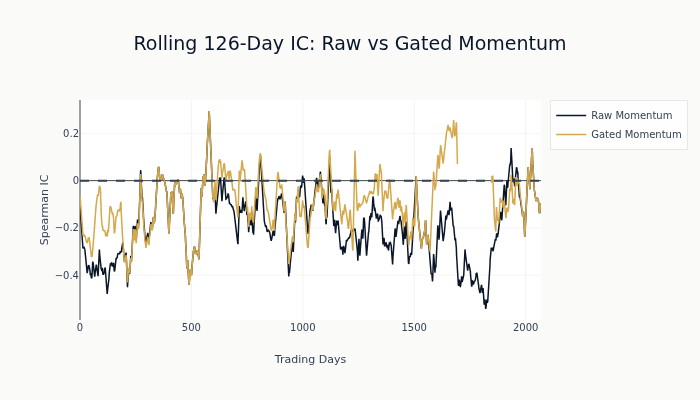

In [20]:
# Rolling IC comparison: raw vs gated
if spy_vol is not None and len(interact_df) > 252:
    ROLL_IC_WINDOW = 126

    ic_raw, ic_gated = [], []
    for i in range(ROLL_IC_WINDOW, len(interact_df)):
        window = interact_df.slice(i - ROLL_IC_WINDOW, ROLL_IC_WINDOW)
        valid = window.drop_nulls(["momentum", "momentum_gated", "fwd_return_5d"])
        if len(valid) > 30:
            ic_r = valid.select(pl.corr("momentum", "fwd_return_5d", method="spearman")).item()
            ic_g = valid.select(
                pl.corr("momentum_gated", "fwd_return_5d", method="spearman")
            ).item()
            ic_raw.append(ic_r)
            ic_gated.append(ic_g)
        else:
            ic_raw.append(np.nan)
            ic_gated.append(np.nan)

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            y=ic_raw, mode="lines", name="Raw Momentum", line=dict(color=COLORS["blue"], width=1.5)
        )
    )
    fig.add_trace(
        go.Scatter(
            y=ic_gated,
            mode="lines",
            name="Gated Momentum",
            line=dict(color=COLORS["amber"], width=1.5),
        )
    )
    fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
    fig.update_layout(
        title="Rolling 126-Day IC: Raw vs Gated Momentum",
        xaxis_title="Trading Days",
        yaxis_title="Spearman IC",
        height=400,
    )
    fig.show()

The gated signal avoids the worst IC drawdowns during high-volatility
episodes, at the cost of fewer active days (reduced breadth). Whether
gating improves net performance depends on the IC gain vs breadth loss -
a question for the modeling chapters (Ch11–12).

## 7. Implementation Variants

Different implementation choices are hyperparameters. A robust signal
should not depend critically on one specific choice. We compare five
momentum variants with the same lookback (63 days).

In [21]:
def _compute_variant_ic(
    signal_df: pl.DataFrame,
    fwd_long: pl.DataFrame,
    symbols: list[str],
) -> dict:
    """Compute HAC-adjusted IC for a signal variant."""
    sig_long = signal_df.unpivot(
        index="timestamp", variable_name="symbol", value_name="signal"
    ).filter(pl.col("signal").is_finite())

    merged = sig_long.join(fwd_long, on=["timestamp", "symbol"], how="inner").drop_nulls()

    ics = []
    for date in merged["timestamp"].unique().sort().to_list():
        day_data = merged.filter(pl.col("timestamp") == date)
        if len(day_data) >= 10:
            sig = day_data["signal"].to_numpy()
            ret = day_data["fwd_ret"].to_numpy()
            valid = np.isfinite(sig) & np.isfinite(ret)
            if np.sum(valid) >= 10:
                ic = pooled_ic(sig[valid], ret[valid])
                if not np.isnan(ic):
                    ics.append(ic)

    return _ic_stats_with_icir(np.array(ics), label_horizon=FORWARD_HORIZON)

In [22]:
LOOKBACK = 63
returns = prices_wide.select(
    pl.col("timestamp"), *[(pl.col(s) / pl.col(s).shift(1) - 1).alias(s) for s in symbols]
)
forward_ret = prices_wide.select(
    pl.col("timestamp"),
    *[(pl.col(s).shift(-FORWARD_HORIZON) / pl.col(s) - 1).alias(s) for s in symbols],
)
fwd_long = forward_ret.unpivot(index="timestamp", variable_name="symbol", value_name="fwd_ret")

impl_results = {}

In [23]:
# Simple price momentum
mom1 = prices_wide.select(
    pl.col("timestamp"),
    *[(pl.col(s) / pl.col(s).shift(LOOKBACK) - 1).alias(s) for s in symbols],
)
impl_results["Simple"] = _compute_variant_ic(mom1, fwd_long, symbols)

# Risk-adjusted (divided by rolling vol)
vol = returns.select(
    pl.col("timestamp"), *[pl.col(s).rolling_std(LOOKBACK).alias(s) for s in symbols]
)
mom2 = mom1.join(vol, on="timestamp", suffix="_vol")
for s in symbols:
    mom2 = mom2.with_columns((pl.col(s) / pl.col(f"{s}_vol").clip(lower_bound=1e-6)).alias(s))
mom2 = mom2.select(["timestamp"] + symbols)
impl_results["Risk-Adjusted"] = _compute_variant_ic(mom2, fwd_long, symbols)

# Skip-month (skip most recent 21 days)
mom3 = prices_wide.select(
    pl.col("timestamp"),
    *[(pl.col(s).shift(21) / pl.col(s).shift(LOOKBACK) - 1).alias(s) for s in symbols],
)
impl_results["Skip-1M"] = _compute_variant_ic(mom3, fwd_long, symbols)

# Log returns
mom4 = prices_wide.select(
    pl.col("timestamp"),
    *[(pl.col(s) / pl.col(s).shift(LOOKBACK)).log().alias(s) for s in symbols],
)
impl_results["Log"] = _compute_variant_ic(mom4, fwd_long, symbols)

# EMA-smoothed
mom5_raw = prices_wide.select(
    pl.col("timestamp"),
    *[(pl.col(s) / pl.col(s).shift(LOOKBACK) - 1).alias(s) for s in symbols],
)
mom5 = mom5_raw.select(pl.col("timestamp"), *[pl.col(s).ewm_mean(span=5).alias(s) for s in symbols])
impl_results["EMA-5"] = _compute_variant_ic(mom5, fwd_long, symbols)

In [24]:
print(f"{'Variant':<18} {'Mean IC':>10} {'ICIR':>8} {'HAC t':>10}")
print("-" * 50)

for name, r in sorted(impl_results.items(), key=lambda x: -x[1]["icir"]):
    sig = "*" if r["p_value"] < 0.05 else ""
    print(f"{name:<18} {r['mean_ic']:>10.4f} {r['icir']:>8.2f} {r['t_stat']:>10.2f}{sig}")

icir_range = max(r["icir"] for r in impl_results.values()) - min(
    r["icir"] for r in impl_results.values()
)
print(f"\nICIR range: {icir_range:.2f}")
print(
    f"ICIR range across implementations: {icir_range:.2f} (threshold for cross-implementation stability: 0.3)"
)

Variant               Mean IC     ICIR      HAC t
--------------------------------------------------
Skip-1M               -0.0072    -0.02      -0.31
Risk-Adjusted         -0.0152    -0.05      -0.71
EMA-5                 -0.0189    -0.06      -0.80
Simple                -0.0195    -0.06      -0.84
Log                   -0.0195    -0.06      -0.84

ICIR range: 0.04
ICIR range across implementations: 0.04 (threshold for cross-implementation stability: 0.3)


## 8. Robustness Summary

In [25]:
print("\n" + "=" * 50)
print("ROBUSTNESS REPORT")
print("=" * 50)

print("\n1. PARAMETER ROBUSTNESS")
if sweep_results and robustness:
    rr = robustness["robust_range"]
    print(f"   Best: {robustness['best_param']}d (ICIR = {robustness['best_value']:.2f})")
    print(f"   Robust range: {rr[0]}-{rr[1]}d" if rr else "   Robust range: None")
    print(f"   Fraction near-optimal: {robustness['robust_fraction']:.0%}")

print("\n2. REGIME ROBUSTNESS")
if spy_vol is not None and regime_ic:
    ic_vals = [r["mean_ic"] for r in regime_ic.values()]
    print(f"   IC range across regimes: {max(ic_vals) - min(ic_vals):.4f}")

print("\n3. IMPLEMENTATION ROBUSTNESS")
if impl_results:
    print(f"   ICIR range: {icir_range:.2f}")
    best = max(impl_results.items(), key=lambda x: x[1]["icir"])
    print(f"   Best variant: {best[0]}")

print("=" * 50)


ROBUSTNESS REPORT

1. PARAMETER ROBUSTNESS
   Best: 189d (ICIR = 0.08)
   Robust range: 189-189d
   Fraction near-optimal: 12%

2. REGIME ROBUSTNESS
   IC range across regimes: 0.1052

3. IMPLEMENTATION ROBUSTNESS
   ICIR range: 0.04
   Best variant: Skip-1M


## Key Takeaways

1. **Robustness is breadth, not a ratio**: The fraction of parameters
   within 90% of best performance, not mean/std
2. **One knob at a time**: Vary lookback while holding everything else
   constant; combine best single-knob settings afterward
3. **Regime conditioning requires care**: Use pre-defined conditioning
   variables (not derived from the signal); only condition when the IC
   range across regimes exceeds noise (>0.04)
4. **Correct for snooping**: After sweeping N parameters, apply RAS to
   deflate the best IC for data-mining bias
5. **Interactions multiply search**: Signal × state combinations must
   enter the searched-set accounting from §7.4

**Next**: `07_event_studies` - event-based signal validation